In [13]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load saved data
close_prices = pd.read_csv("../data/close_prices.csv", index_col="Date", parse_dates=True)

print("Shape:", close_prices.shape)
print("\nColumns:", close_prices.columns.tolist())
close_prices.head()

Shape: (1238, 5)

Columns: ['HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'TCS.NS']


,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2020-01-01,605.529358,519.137939,633.151123,672.216064,1841.149414
2020-01-02,609.389160,522.861572,631.303650,683.660278,1832.698120
2020-01-03,600.698792,521.169006,641.013428,684.484009,1869.222290
2020-01-06,587.698853,508.450592,634.869690,668.609253,1869.052246
2020-01-07,597.004822,505.742401,625.460693,678.895691,1873.638794


In [14]:
print("Null Values:")
null_values = close_prices.isnull().sum()
print(null_values)

total_values = len(close_prices)
print("\nNull Percentage:")
print((null_values/total_values * 100).round(2))


Null Values:
HDFCBANK.NS     0
ICICIBANK.NS    0
INFY.NS         0
RELIANCE.NS     0
TCS.NS          0
dtype: int64

Null Percentage:
HDFCBANK.NS     0.0
ICICIBANK.NS    0.0
INFY.NS         0.0
RELIANCE.NS     0.0
TCS.NS          0.0
dtype: float64


In [15]:
print("Basic Statistics:")
print(close_prices.describe().round(2))

Basic Statistics:
       HDFCBANK.NS  ICICIBANK.NS  INFY.NS  RELIANCE.NS   TCS.NS
count      1238.00       1238.00  1238.00      1238.00  1238.00
mean        703.89        775.96  1299.01      1095.10  2948.57
std         107.02        265.58   332.36       230.48   638.87
min         363.57        274.68   452.36       393.66  1403.24
25%         664.35        588.28  1168.05       951.00  2697.68
50%         720.41        777.28  1357.81      1115.59  2991.24
75%         780.58        938.77  1513.60      1219.33  3311.67
max         923.39       1335.79  1942.22      1581.82  4253.91


In [39]:
first_price = close_prices.iloc[0]
last_price = close_prices.iloc[-1]

total_return = ((last_price - first_price) / first_price * 100).round(2)

print("Total Return (2020-2025):")
for stock,ret in total_return.sort_values(ascending = False).items():
    print(f"{stock}: {ret}%")
    
print(f"\n\nHighest Return - {total_return.idxmax()} : {total_return.max()}%")

Total Return (2020-2025):
INFY.NS: 188.39%
ICICIBANK.NS: 144.99%
TCS.NS: 108.27%
RELIANCE.NS: 79.26%
HDFCBANK.NS: 44.44%


Highest Return - INFY.NS : 188.39%


In [40]:
cv = (close_prices.std() / close_prices.mean() * 100).round(2)

print("Risk (Coefficient of Variation) : ")

for stock,ret in cv.sort_values(ascending = False).items():
    print(f"{stock} : {ret}%")

print(f"\n\nHighest Risk - {cv.idxmax()} : {cv.max()}") 

Risk (Coefficient of Variation) : 
ICICIBANK.NS : 34.23%
INFY.NS : 25.59%
TCS.NS : 21.67%
RELIANCE.NS : 21.05%
HDFCBANK.NS : 15.2%


Highest Risk - ICICIBANK.NS : 34.23


In [42]:
correlation = close_prices.corr().round(2)

print("Correlation Matrix:  ")
print(correlation)

Correlation Matrix:  
              HDFCBANK.NS  ICICIBANK.NS  INFY.NS  RELIANCE.NS  TCS.NS
HDFCBANK.NS          1.00          0.85     0.82         0.73    0.84
ICICIBANK.NS         0.85          1.00     0.80         0.87    0.90
INFY.NS              0.82          0.80     1.00         0.81    0.94
RELIANCE.NS          0.73          0.87     0.81         1.00    0.90
TCS.NS               0.84          0.90     0.94         0.90    1.00


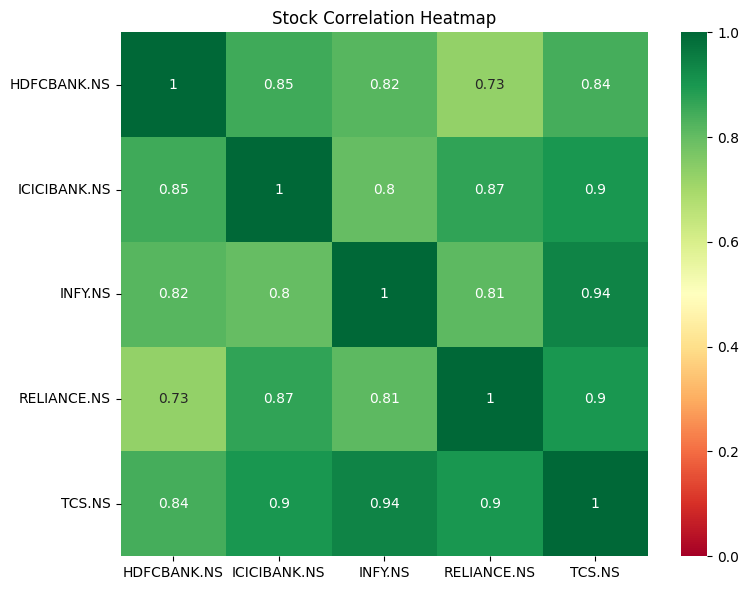

In [43]:
plt.figure(figsize = (8,6))
sns.heatmap(correlation, 
            annot = True,
            cmap = 'RdYlGn',
            vmin = 0, vmax = 1)
plt.title("Stock Correlation Heatmap")
plt.tight_layout()
plt.savefig("../data/correlation_heatmap.png")
plt.show()